# Theory calculator Magnetic accelerator

## All Constants + Parameters

In [17]:
import math
mu0 =1.25663706127e-6
V = math.pi*0.035/2*0.035/2*0.004 #volume of cylinder
Br_cube = 1.306
Br_cyl = 1.215
mag_amt = 8 # amount of magnets along y
angle = 83
s_cube = 0.01 #side of cube
d_cu_cu = 0.011 #distance between cubes
d = -0.04 #x distance cyl - edge of plate
start_x, start_y = d - 0.02 ,0 #place of the wheel in the rilles in my setup relative to the starting magnet, first row
mag_diam = 0.035 #diameter of magnet
m_cyl = (Br_cyl*V)/mu0
M_vehicle = 0.07125
rolling_start_y = 0.025
rolling_end_y = 0.225
half_length_cube = 0.005 #half length of cube

## Calculation of magnetic field

AI Prompt: change this to python code: [Javascript Class for magnets](javascript)

In [18]:
import math

const_mag = -Br_cube / (4 * math.pi)

class Magnet:
    def __init__(self, a, b, c, x, y, z):
        self.a = a
        self.b = b
        self.c = c
        self.x = x
        self.y = y
        self.z = z

    def calculateF(self, px, py, pz):
        xna = px + self.a
        ynb = py + self.b
        znc = pz + self.c
        dist = math.sqrt(xna * xna + ynb * ynb + znc * znc)
        temp = (xna * ynb) / (znc * dist)
        return math.atan(temp)

    def calculateB(self):
        c1 = self.calculateF(-self.x, self.y, self.z)
        c2 = self.calculateF(self.x, -self.y, self.z)
        c3 = self.calculateF(self.x, self.y, -self.z)
        c4 = self.calculateF(-self.x, -self.y, self.z)
        c5 = self.calculateF(-self.x, self.y, -self.z)
        c6 = self.calculateF(self.x, -self.y, -self.z)
        c7 = self.calculateF(-self.x, -self.y, -self.z)
        c8 = self.calculateF(self.x, self.y, self.z)
        sum_values = c1 + c2 + c3 + c4 + c5 + c6 + c7 + c8
        return const_mag * sum_values

magnet1 = Magnet(half_length_cube, half_length_cube, half_length_cube, -0.06, 0.06, 0.035/2) # x = -0.06, y = 0.06, z = 0.035/2 is just the starting place for the sweep across 
print(magnet1.calculateB())


-0.00014024813436165813


### Plot of B-field for starting magnet

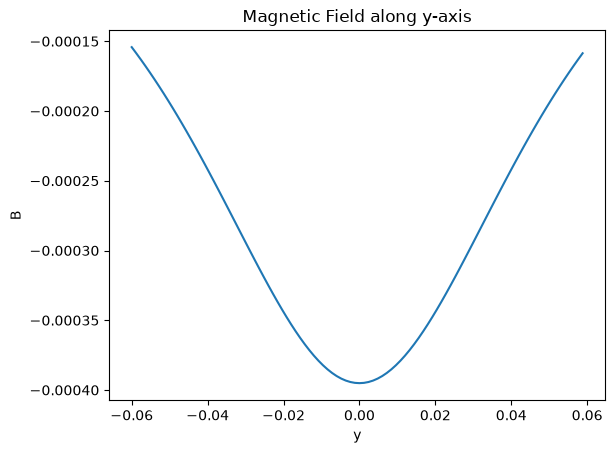

In [19]:
import matplotlib.pyplot as plt

arrayB = []
for i in range(0, 100):
    y = -0.06 + i * 0.0012 #y-sweep starting 6 cm back, goin ginto +y
    magnet1 = Magnet(half_length_cube, half_length_cube, half_length_cube, start_x, y, mag_diam/2 - half_length_cube)
    B = magnet1.calculateB()
    arrayB.append(B)

plt.plot([(-0.06 + i * 0.0012) for i in range(0, 100)], arrayB)
plt.xlabel('y')
plt.ylabel('B')
plt.title('Magnetic Field along y-axis')
plt.show()

## Generation of positions for all 10 magnets

In [20]:
array_mags_pos = [] #array containg all position arrays of all magnets
for i in range(0, mag_amt, 1):
    array_mags_pos.append([i*math.tan(math.radians(90-angle))*(s_cube + d_cu_cu), i * (s_cube + d_cu_cu)])

## Plot of B_field of 10 magnets

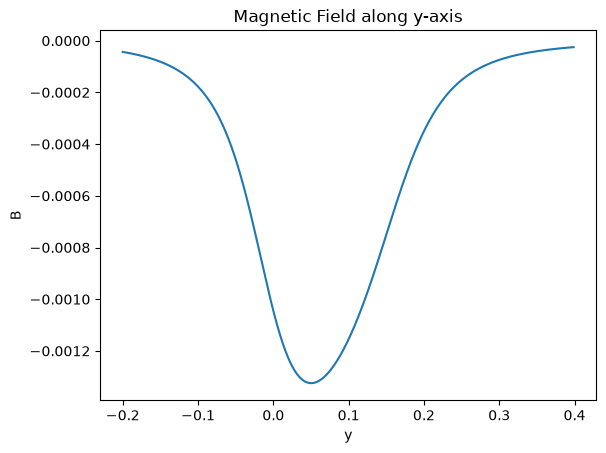

In [21]:
import matplotlib.pyplot as plt

arrayB = []
for i in range(0, 500):
    y = -0.2 + i * 0.0012 #y-sweep starting 6 cm back, going into +y
    B = 0
    for magnet_x, magnet_y in array_mags_pos:
        magnet = Magnet(half_length_cube, half_length_cube, half_length_cube, start_x - magnet_x, y - magnet_y, mag_diam/2)
        B += magnet.calculateB()
    arrayB.append(B)

array_y =[]
for i in range(0, 500):
    array_y.append((-0.2 + i * 0.0012))

plt.plot(array_y, arrayB)
plt.xlabel('y')
plt.ylabel('B')
plt.title('Magnetic Field along y-axis')
plt.show()

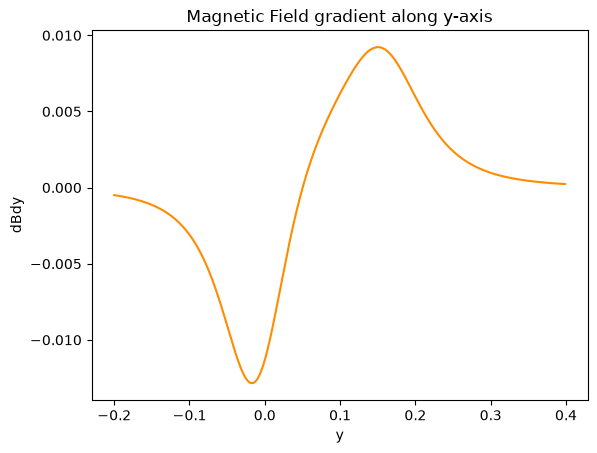

In [22]:
import numpy as np
dBdy = np.gradient(arrayB, array_y)

plt.plot(array_y, dBdy, color = "darkorange")
plt.xlabel('y')
plt.ylabel('dBdy')
plt.title('Magnetic Field gradient along y-axis')
plt.show()

## Acceleration function with parameter y

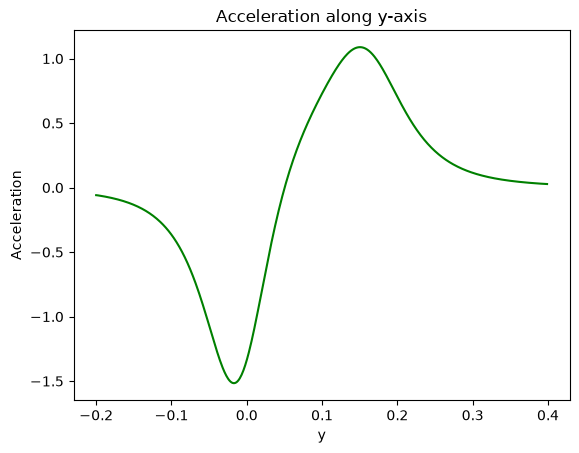

In [23]:
a_cyl = []

for i in range(len(dBdy)):
    a_cyl.append((2 * m_cyl * 1.13 * dBdy[i])/M_vehicle)

plt.plot(array_y, a_cyl, color = "green")
plt.xlabel('y')
plt.ylabel('Acceleration')
plt.title('Acceleration along y-axis')
plt.show()

## Attempt to find the analytical expression for a(y)

## Using Scipy's RK45 to simulate time and position at each "IR sensor" position 

SciPy - Integration of Ordinary Differential Equations. (o. D.). https://www.tutorialspoint.com/scipy/scipy_integration_of_ordinary_differential_equations.htm

In [24]:
from scipy.integrate import solve_ivp
import numpy as np

# Define the ODE system
def fun(t, y):
    return -0.5 * y

# Time span and initial condition
t_span = (0, 10)
y0 = [2]

# Solve ODE
sol = solve_ivp(fun, t_span, y0, method='RK45', t_eval=np.linspace(0, 10, 100))

# Access the solution
print(sol.t)  # Time points
print(sol.y)  # Solution values at the time points

[ 0.          0.1010101   0.2020202   0.3030303   0.4040404   0.50505051
  0.60606061  0.70707071  0.80808081  0.90909091  1.01010101  1.11111111
  1.21212121  1.31313131  1.41414141  1.51515152  1.61616162  1.71717172
  1.81818182  1.91919192  2.02020202  2.12121212  2.22222222  2.32323232
  2.42424242  2.52525253  2.62626263  2.72727273  2.82828283  2.92929293
  3.03030303  3.13131313  3.23232323  3.33333333  3.43434343  3.53535354
  3.63636364  3.73737374  3.83838384  3.93939394  4.04040404  4.14141414
  4.24242424  4.34343434  4.44444444  4.54545455  4.64646465  4.74747475
  4.84848485  4.94949495  5.05050505  5.15151515  5.25252525  5.35353535
  5.45454545  5.55555556  5.65656566  5.75757576  5.85858586  5.95959596
  6.06060606  6.16161616  6.26262626  6.36363636  6.46464646  6.56565657
  6.66666667  6.76767677  6.86868687  6.96969697  7.07070707  7.17171717
  7.27272727  7.37373737  7.47474747  7.57575758  7.67676768  7.77777778
  7.87878788  7.97979798  8.08080808  8.18181818  8